# Flow Matching Models

This notebook introduces **Conditional Flow Matching (CFM)**, a family of generative models based on continuous normalizing flows. The examples are adapted from [facebookresearch/flow_matching](https://github.com/facebookresearch/flow_matching).

[Carlo Aironi](mailto:c.aironi@staff.univpm.it), 2026


### What is Flow Matching?

The core idea is to learn a **velocity field** $v_\theta(t, x)$ that transports a simple source distribution $p_0$ (typically a Gaussian) toward a complex target distribution $p_1$ (the real data), following a continuous path over time $t \in [0, 1]$.

Each point travels along a trajectory governed by an **ODE** (Ordinary Differential Equation):

$$\frac{dx}{dt} = v_\theta(t, x_t)$$

Training is essentially a regression problem: the model learns to predict the direction and speed at which points move along the flow at any given time.


### Terminology: "Conditional" vs "Conditioned"

These two terms are easy to mix up, but they refer to different things:

- **Conditional Flow Matching (CFM)**: refers to the *training technique*. The velocity field is estimated by conditioning on pairs of points $(x_0, x_1)$, one noise sample and one real data point. This pairing lets us construct simple, straight-line flow paths, making training stable and scalable. It is a training-time concept, not an inference-time one.

- **Conditioned generation**: refers to the classical notion of conditioning a generative model on external information such as **class labels** or other attributes, in the same sense as conditional GANs or conditional Diffusion Models. Section 2 of this notebook demonstrates a model that generates samples conditioned on a class label $c$.

In short: CFM is always "conditional" in the training sense. Only the model in Section 2 is also "conditioned" in the generative sense.

In [1]:
import sys
import numpy as np
import torch
from torch import nn, Tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

### 1. Unconditioned CFM

The `Flow` network is a simple MLP implementing the velocity field $v_\theta(t, x_t)$.

**Input**: the continuous time scalar $t \in [0,1]$ (one value per sample) concatenated with the current position $x_t \in \mathbb{R}^2$, giving a total input dimension of `dim + 1 = 3`.

**Output**: the predicted velocity field $\hat{v} \in \mathbb{R}^2$ — the direction and speed at which each point should move at that timestep.

**Architecture**: 3 hidden layers with ELU activations and hidden size `h=64`. ELU or SiLU are preferred over ReLU activations because they produce non-zero gradients for negative inputs, which is useful when learning smooth, continuous vector fields.

**The `step()` method** implements one integration step of the ODE using **2nd-order Runge-Kutta (RK2)**, also known as the *midpoint method*. Rather than evaluating the velocity field at the start of the interval (Euler's method), it evaluates it at the **midpoint** $t_{mid} = t_{start} + \Delta t / 2$, using an intermediate position estimate:

$$x_{mid} = x_t + v_\theta(t_{start}, x_t) \cdot \frac{\Delta t}{2}$$
$$x_{t+\Delta t} = x_t + v_\theta\!\left(t_{mid},\, x_{mid}\right) \cdot \Delta t$$

This reduces the truncation error from $O(\Delta t^2)$ (Euler) to $O(\Delta t^3)$, giving accurate trajectories even with a small number of integration steps.

In [2]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))

    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)

        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

#### 1.1 Training

The training loop implements **Conditional Flow Matching** in its simplest form, using straight-line (Optimal Transport) paths.

At each iteration:

1. **Data sampling**: `x_1` is a batch of real points from the target distribution (`make_moons`), normalized to zero mean and unit variance.

2. **Noise sampling**: `x_0` is a batch of Gaussian samples $\mathcal{N}(0, I)$ with the same shape as `x_1`. Each pair $(x_0^{(i)}, x_1^{(i)})$ defines a flow trajectory.

3. **Time sampling**: `t` is drawn uniformly from $[0, 1]$ — one scalar per sample.

4. **Linear interpolation** (conditional flow path):
$$x_t = (1 - t) \cdot x_0 + t \cdot x_1$$
This is the "flow path" connecting $x_0$ to $x_1$ in a straight line. The point $x_t$ is where the sample should be at time $t$.

5. **Target velocity field**:
$$\dot{x}_t = x_1 - x_0$$
For a linear path, the velocity field is constant along the trajectory and equal to the displacement $x_1 - x_0$. This is what the model needs to learn to predict.

6. **Loss**: **Huber Loss** between the predicted and target velocity fields. Huber Loss is more robust to outliers than MSE, which helps during the early stages of training.

The key insight of CFM is that we never need to simulate full trajectories during training: we sample $t$ directly, compute $x_t$ in closed form, and regress on the velocity field. This makes training significantly more efficient than classical Diffusion Models.

In [3]:
b_size = 256
model = Flow()
loss_buf = []
optimizer = torch.optim.Adam(model.parameters(), 1e-2)
loss_fn = nn.HuberLoss()

for _ in tqdm(range(10000)):
    x_1 = Tensor(make_moons(b_size, noise=0.05)[0])
    x_1 = (x_1 - x_1.mean(0)) / x_1.std(0)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    l = loss_fn(model(t=t, x_t=x_t), dx_t)
    loss_buf.append(l.item())
    l.backward()
    optimizer.step()

100%|██████████| 10000/10000 [00:31<00:00, 312.64it/s]


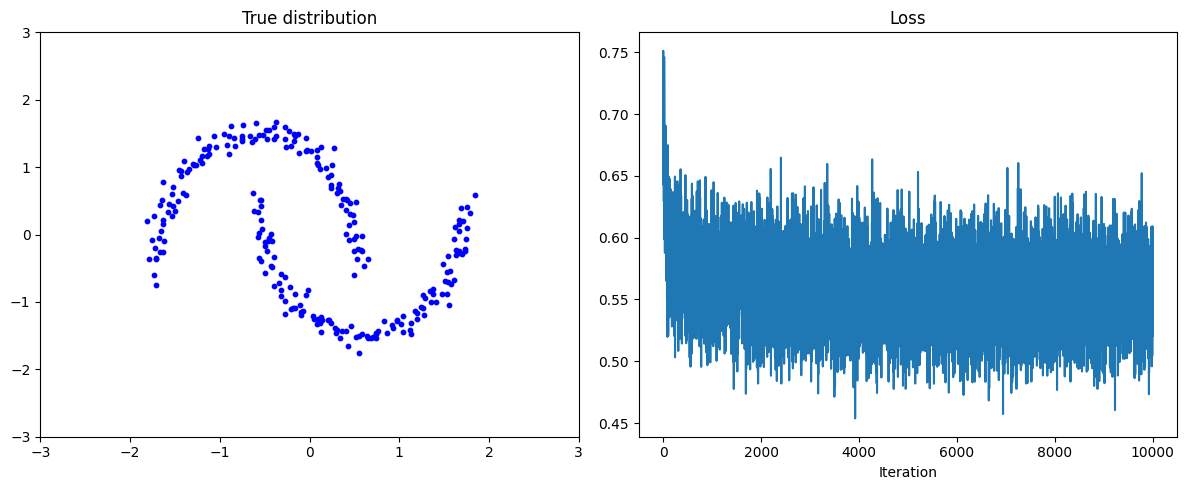

In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(x_1[:, 0], x_1[:, 1], s=10, c='blue')
plt.title('True distribution')
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.subplot(1,2,2)
plt.plot(loss_buf)
plt.title('Loss')
plt.xlabel('Iteration')
plt.tight_layout()
plt.show()

#### 1.2 Sampling

The sampling cell traces the ODE forward in time: starting from Gaussian noise $x \sim \mathcal{N}(0, I)$ at $t=0$, we numerically integrate the learned velocity field up to $t=1$, producing samples from the target distribution.

The integration runs over `n_steps = 10` evenly spaced timesteps $[0.0, 0.1, \ldots, 1.0]$. At each step, `model.step()` (RK2) updates the positions of all points.

The output is a sequence of scatter plots showing the **progressive deformation** of the distribution: the Gaussian cloud gradually morphs into the two-moon shape. The fact that just 10 steps already produce clean results highlights the efficiency of higher-order integrators compared to plain Euler.

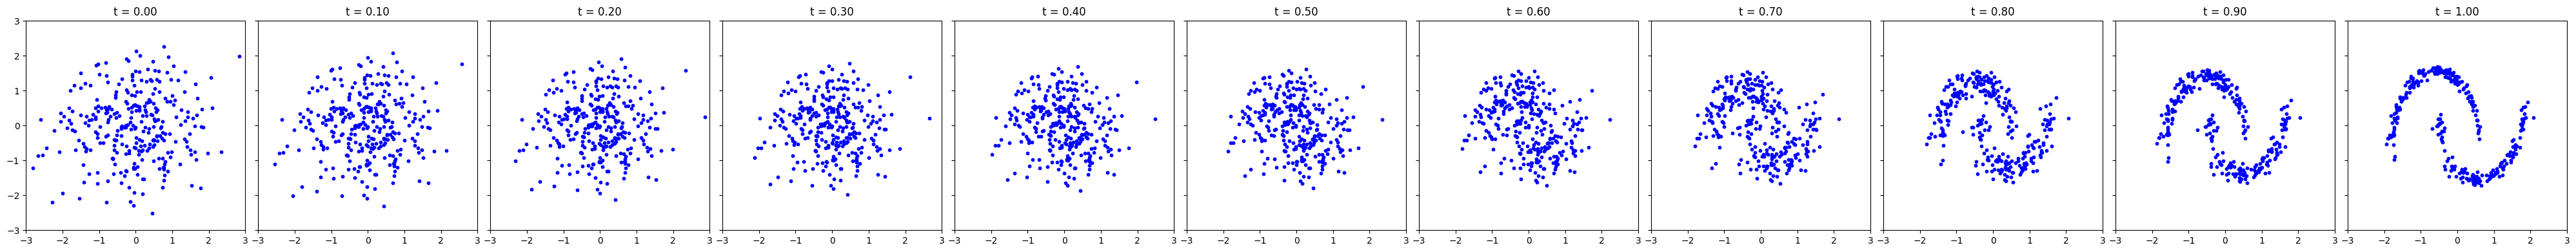

In [5]:
n_samples = 300
x = torch.randn(n_samples, 2)
n_steps = 10
fig, axes = plt.subplots(1, n_steps + 1, figsize=(40, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10, c='blue')
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

with torch.no_grad():
    for i in range(n_steps):
        x = model.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
        axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10, c='blue')
        axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

### 2. Conditioned CFM

The `ConditionedFlow` model extends the previous one by incorporating **class label conditioning** $c \in \{0, 1\}$, passed as an additional input to the network.

**Architectural differences from Unconditioned `Flow`**:

- **Larger input**: the input grows from `dim + 1 = 3` to `dim + 2 = 4`, adding the scalar label $c$ to the concatenation `[t, c, x_t]`.
- **Updated signatures**: both `forward()` and `step()` now take a `c: Tensor` parameter, which is forwarded at every velocity field evaluation, including the RK2 midpoint step.

**What changes conceptually**: the model now learns a *class-specific* velocity field $v_\theta(t, c, x_t)$. The network effectively learns two separate flows, one for each moon, guided by the label. At sampling time, specifying $c=0$ or $c=1$ steers the generated points toward the corresponding class distribution.

**Training** (cell 2.1) is identical to the unconditioned case, with the only addition that `c` (the class labels from `make_moons`) is extracted and passed to the model. Labels are reshaped to `(-1, 1)` for compatibility with vector concatenation.

**Sampling** (cell 2.2) assigns random labels to the noise samples and integrates the flow. Points are colored by class (`blue`/`orange`) so you can visually verify that each class converges to the correct moon.

In [6]:
class ConditionedFlow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 2, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))

    def forward(self, t: Tensor, c: Tensor, x_t: Tensor ) -> Tensor:
        return self.net(torch.cat((t, c, x_t), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, c: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)

        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, c = c, x_t= x_t + self(c = c, x_t=x_t, t=t_start) * (t_end - t_start) / 2)

#### 2.1 Training

In [7]:
b_size = 256
model = ConditionedFlow()
loss_buf = []
optimizer = torch.optim.Adam(model.parameters(), 1e-2)
loss_fn = nn.HuberLoss()

for _ in tqdm(range(10000)):
    x_1, c = make_moons(b_size, noise=0.05)
    x_1 = Tensor(x_1)
    x_1 = (x_1 - x_1.mean(0)) / x_1.std(0)
    c = Tensor(c)
    c = c.view(-1, 1)

    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    l = loss_fn(model(t=t, x_t=x_t, c=c), dx_t)
    loss_buf.append(l.item())
    l.backward()
    optimizer.step()

100%|██████████| 10000/10000 [00:35<00:00, 285.04it/s]


#### 2.2 Sampling

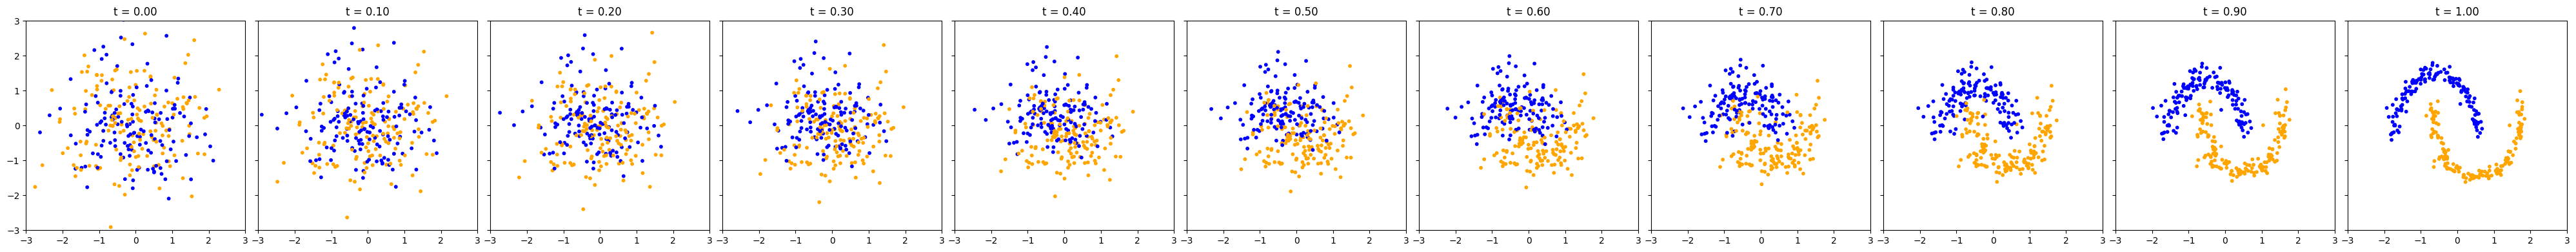

In [8]:
n_samples = 300
x = torch.randn(n_samples, 2)

# labels
c_eval = torch.randint(0, 2, (n_samples, 1), dtype=torch.float32)
# point colors
colors = ['blue' if lbl == 0 else 'orange' for lbl in c_eval.squeeze().tolist()]

n_steps = 10
fig, axes = plt.subplots(1, n_steps + 1, figsize=(40, 4), sharex=True, sharey=True)

time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x[:, 0], x[:, 1], s=10, c=colors)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

with torch.no_grad():
    for i in range(n_steps):
        x = model.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1], c=c_eval)
        axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10, c=colors)
        axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

### Discrete Flow Matching (DFM)

**Discrete Flow Matching** extends the CFM framework to discrete spaces, where data consists of sequences of **tokens** from a finite vocabulary of size $V$, rather than continuous vectors.

#### Analogies with continuous CFM

As in continuous CFM, the goal is to transport a simple source distribution (random tokens) toward the target distribution (real data), guided by a time-parameterized process $t \in [0, 1]$.

The training principle is the same: sample an intermediate state $x_t$ between noise $x_0$ and real data $x_1$, and train the model to predict $x_1$ from $(x_t, t)$.

#### Key differences from continuous CFM

| Aspect | Continuous CFM | DFM |
|---|---|---|
| Data space | $\mathbb{R}^d$ | $\{0, \ldots, V-1\}^d$ |
| Source distribution | Gaussian | Uniform random tokens |
| Interpolation | $x_t = (1-t)x_0 + tx_1$ | Stochastic per-token substitution |
| Model output | Velocity field $\hat{v} \in \mathbb{R}^d$ | Logits over vocabulary $\hat{p} \in \mathbb{R}^{d \times V}$ |
| Loss | MSE / Huber | Cross-entropy |
| Integration step | ODE (RK2) | Categorical sampling |

#### Network structure and the role of Embedding

The network can't simply take integer token indices as real-valued inputs: raw indices have no meaningful geometry (token 3 is not inherently "closer" to token 4 than to token 10).

This is why we use an **`nn.Embedding(v, h)`** layer: each token is mapped to a learned continuous vector of dimension `h=128`. The embedding transforms the token sequence $x_t \in \{0,\ldots,V-1\}^2$ into a continuous vector of dimension `dim * h = 256`, which is then concatenated with $t$ and fed to the MLP.

The output has dimension `dim * v = 128`, reshaped to `[batch, dim, vocab_size]`: for each position and each vocabulary token, the network returns an unnormalized logit.

#### 3.1 Dataset

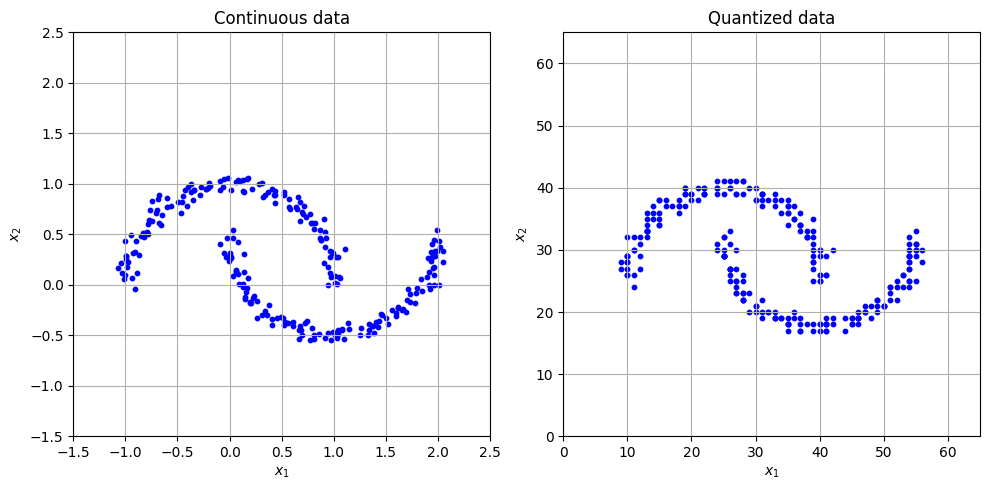

In [14]:
batch_size = 256
vocab_size = 64

# Dataset continuo
x_cont = torch.tensor(make_moons(batch_size, noise=0.05)[0])

# Dataset discreto (stesso preprocessing del DFM)
x_disc = torch.round(torch.clip(x_cont *15 + 25, min=0.0, max=vocab_size - 1)).long()

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)

# Continuous
ax[0].scatter(x_cont[:, 0], x_cont[:, 1], s=10, c = 'blue')
ax[0].set_title("Continuous data")
ax[0].set_xlabel(r"$x_1$")
ax[0].set_ylabel(r"$x_2$")
ax[0].set_xlim(-1.5, 2.5)
ax[0].set_ylim(-1.5, 2.5)
ax[0].grid(True)

# Quantized
ax[1].scatter(x_disc[:, 0], x_disc[:, 1], s=10, c = 'blue')
ax[1].set_title("Quantized data")
ax[1].set_xlabel(r"$x_1$")
ax[1].set_ylabel(r"$x_2$")
ax[1].set_xlim(0.0, 65.0)
ax[1].set_ylim(0.0, 65.0)
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
class DiscreteFlow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 128, v: int = 128):
        super().__init__()
        self.v = v
        self.embed = nn.Embedding(v, h)
        self.net = nn.Sequential(
            nn.Linear(dim * h + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim * v))

    def forward(self, x_t: Tensor, t: Tensor) -> Tensor:
        return self.net(torch.cat((t[:, None], self.embed(x_t).flatten(1, 2)), -1)).reshape(list(x_t.shape) + [self.v])

#### 3.1 Training

The DFM training loop follows the same philosophy as continuous CFM, adapted for the discrete setting.

At each iteration:

1. **Data sampling**: `x_1` contains real data points (the quantized moon as tokens), with integer values in $[0, V-1]$.

2. **Noise sampling**: `x_0` is a batch of uniformly random tokens in $[0, V-1]$ — the discrete equivalent of Gaussian noise.

3. **Time sampling**: `t` is uniform in $[0, 1]$, one scalar per sample.

4. **Discrete interpolation**:
$$x_t^{(i,d)} = \begin{cases} x_1^{(i,d)} & \text{with probability } t^{(i)} \\ x_0^{(i,d)} & \text{otherwise} \end{cases}$$
Implemented with `torch.where(torch.rand(...) < t[:, None], x_1, x_0)`. At $t=0$ we start from pure noise; at $t=1$ we are at the real data. For intermediate values of $t$, each token is independently "revealed" with probability $t$.

5. **Loss**: **cross-entropy** between predicted logits and target tokens `x_1`. The model learns to predict the real data from any partially corrupted state — analogous to how the continuous model learns the target velocity field $x_1 - x_0$.

In [11]:
batch_size = 256
vocab_size = 64

model = DiscreteFlow(v=vocab_size)
optim = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in tqdm(range(10000)):
    x_1 = Tensor(make_moons(batch_size, noise=0.05)[0])
    x_1 = torch.round(torch.clip(x_1 * 15 + 25, min=0.0, max=vocab_size - 1)).long()
    x_0 = torch.randint(low=0, high=vocab_size, size=(batch_size, 2))

    t = torch.rand(batch_size)
    x_t = torch.where(torch.rand(batch_size, 2) <  t[:, None], x_1, x_0)

    logits = model(x_t, t)
    loss = nn.functional.cross_entropy(logits.flatten(0, 1), x_1.flatten(0, 1)).mean()
    optim.zero_grad()
    loss.backward()
    optim.step()

100%|██████████| 10000/10000 [01:17<00:00, 128.61it/s]


#### 3.2 Sampling

The DFM sampling loop starts from random tokens and iteratively refines them toward samples from the target distribution.

**Integration scheme**:

At each step with current time $t$ and step size $h$:

1. **Prediction**: the network computes $p_1(x | x_t, t)$, the distribution over real tokens given the current corrupted state, obtained via `softmax` on the logits.

2. **Discrete velocity field**: the "direction" of the flow in probability space:
$$u = \frac{p_1 - \text{onehot}(x_t)}{1 - t}$$
This is the discrete analog of the continuous velocity field $(x_1 - x_t)/(1-t)$: it pushes the distribution from the current token $x_t$ toward the predicted target $p_1$.

3. **Step**: the next token is sampled from the updated distribution:
$$x_{t+h} \sim \text{Categorical}\!\left(\text{onehot}(x_t) + h \cdot u\right)$$

4. **Step size clamping**: $h$ is clipped to `min(0.1, 1.0 - t)` to avoid overshooting $t=1$.

The loop ends when $t$ reaches $1 - \epsilon$. As in the continuous case, the output is a sequence of scatter plots showing the progressive "crystallization" of random tokens into the quantized two-moon shape.

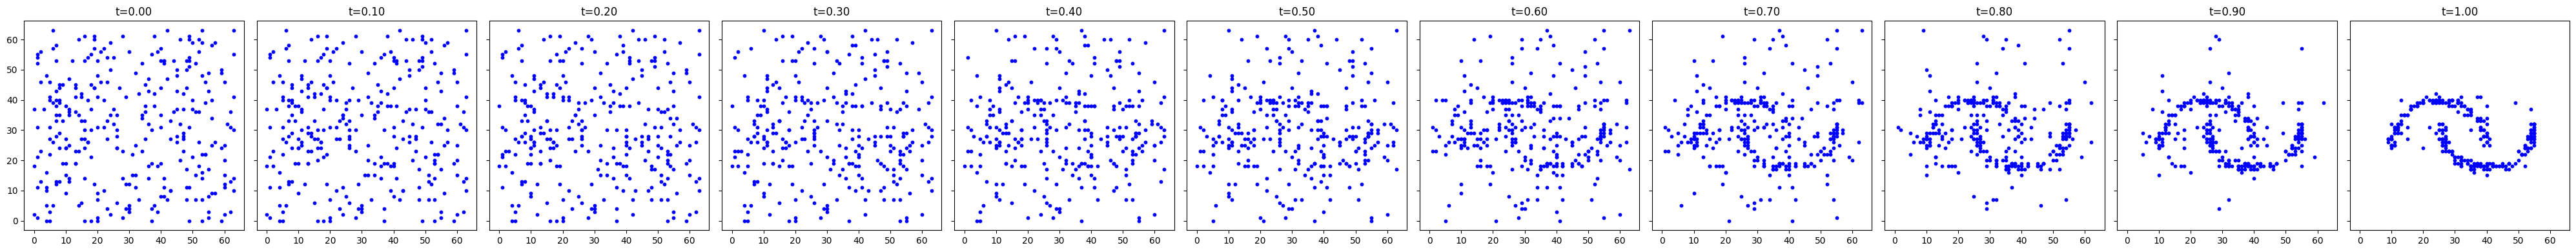

In [12]:
n_samples = 300
x_t = torch.randint(low=0, high=vocab_size, size=(n_samples, 2))
t = 0.0
results = [(x_t, t)]
with torch.no_grad():
    while t < 1.0 - 1e-3:
        p1 = torch.softmax(model(x_t, torch.ones(n_samples) * t), dim=-1)
        h = min(0.1, 1.0 - t)
        one_hot_x_t = nn.functional.one_hot(x_t, vocab_size).float()
        u = (p1 - one_hot_x_t) / (1.0 - t)
        x_t = torch.distributions.Categorical(probs=one_hot_x_t + h * u).sample()
        t += h
        results.append((x_t, t))

fig, axes = plt.subplots(1, len(results), figsize=(40, 4), sharex=True, sharey=True)

for (x_t, t), ax in zip(results, axes):
    ax.scatter(x_t.detach()[:, 0], x_t.detach()[:, 1], s=10, c='blue')
    ax.set_title(f't={t:.2f}')

plt.tight_layout()
plt.show()